# Ekstraksi dan Seleksi Fitur Tekstur GLCM pada Dataset Rambu Lalu Lintas
Dataset terdiri dari 10 citra JPG: 5 jenis rambu (Stop, Km, Kuning, Biru, Dilarang) × 2 citra. Ekstraksi fitur tekstur menggunakan GLCM (OpenCV & scikit-image), dilanjutkan seleksi fitur dengan Filter Method (korelasi Pearson).

Anggota Kelompok:
1. 71231042 - Revaldo Fransisco Hohary
2. 71231050 - Samuel Natanael
3. 71241154 - Indira Mai Narwastu

Link source code dan dataset: https://github.com/indiraamn/Ekstraksi-Fitur-ML05.git

In [1]:
import os
import re
import csv
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops

## Tahap 1: Membaca Dataset Citra
`cv2.imread()` memuat setiap gambar JPG ke dalam matriks tiga dimensi (tinggi, lebar, saluran warna BGR). Ukuran citra diseragamkan agar perbandingan antar citra adil.

rambuBiru1.jpg            ukuran asli: (509, 339, 3)
rambuBiru2.jpg            ukuran asli: (408, 612, 3)
rambuDilarang1.jpg        ukuran asli: (339, 509, 3)
rambuDilarang2.jpg        ukuran asli: (334, 500, 3)
rambuKm1.jpg              ukuran asli: (511, 338, 3)
rambuKm2.jpg              ukuran asli: (408, 612, 3)
rambuKuning1.jpg          ukuran asli: (1800, 1200, 3)
rambuKuning2.jpg          ukuran asli: (414, 414, 3)
rambuStop1.jpg            ukuran asli: (1024, 576, 3)
rambuStop2.jpg            ukuran asli: (550, 550, 3)

Total citra terbaca: 10


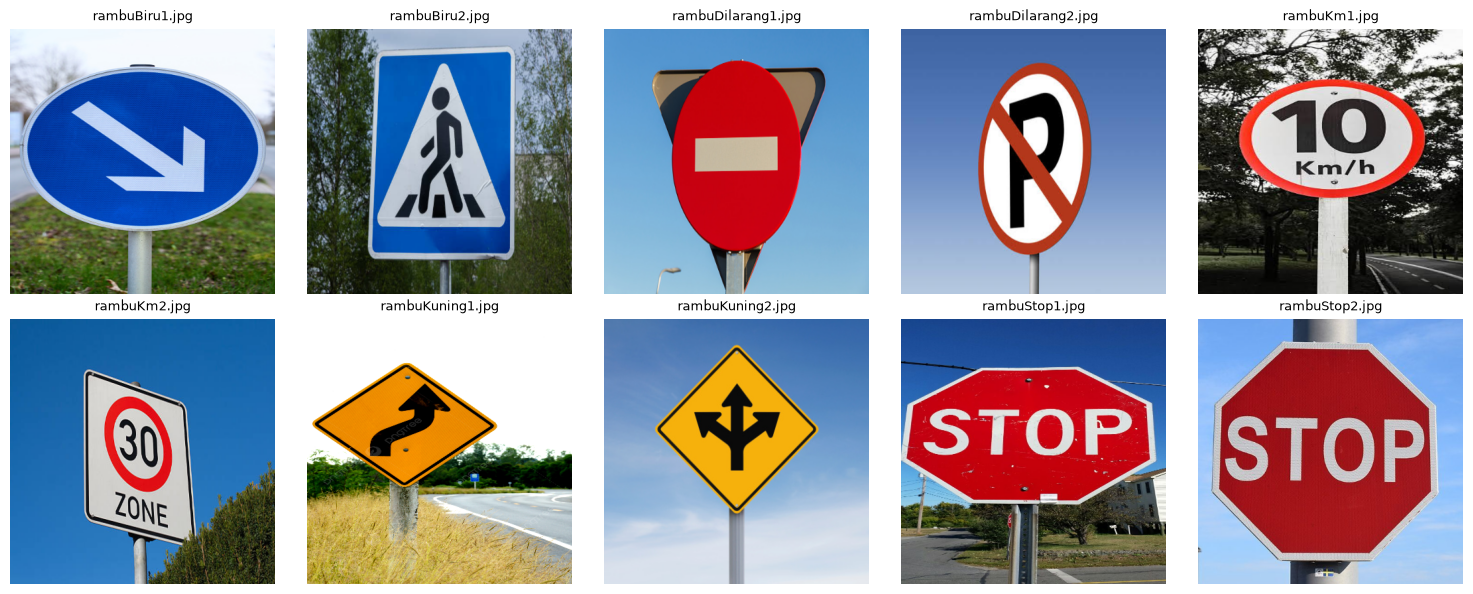

In [2]:
folder = 'dataset_rambu'
daftar_file = sorted([f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg'))])

nama_list, kelas_list, citra_bgr_list = [], [], []

for f in daftar_file:
    img = cv2.imread(os.path.join(folder, f))
    if img is None:
        print(f"[GAGAL] {f} tidak terbaca")
        continue
    print(f"{f:25s} ukuran asli: {img.shape}")
    img = cv2.resize(img, (400, 400))          # penyeragaman ukuran (tambahan)
    nama = os.path.splitext(f)[0]
    kelas = re.sub(r'^rambu', '', re.sub(r'\d+$', '', nama))
    nama_list.append(f)
    kelas_list.append(kelas)
    citra_bgr_list.append(img)

print(f"\nTotal citra terbaca: {len(citra_bgr_list)}")

plt.figure(figsize=(15, 6))
for i, img in enumerate(citra_bgr_list):
    plt.subplot(2, 5, i + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(nama_list[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

## Tahap 2: Pre-processing (Konversi ke Grayscale)
Mengeliminasi informasi warna yang tidak diperlukan karena analisis tekstur umumnya hanya membutuhkan informasi intensitas cahaya (grayscale).

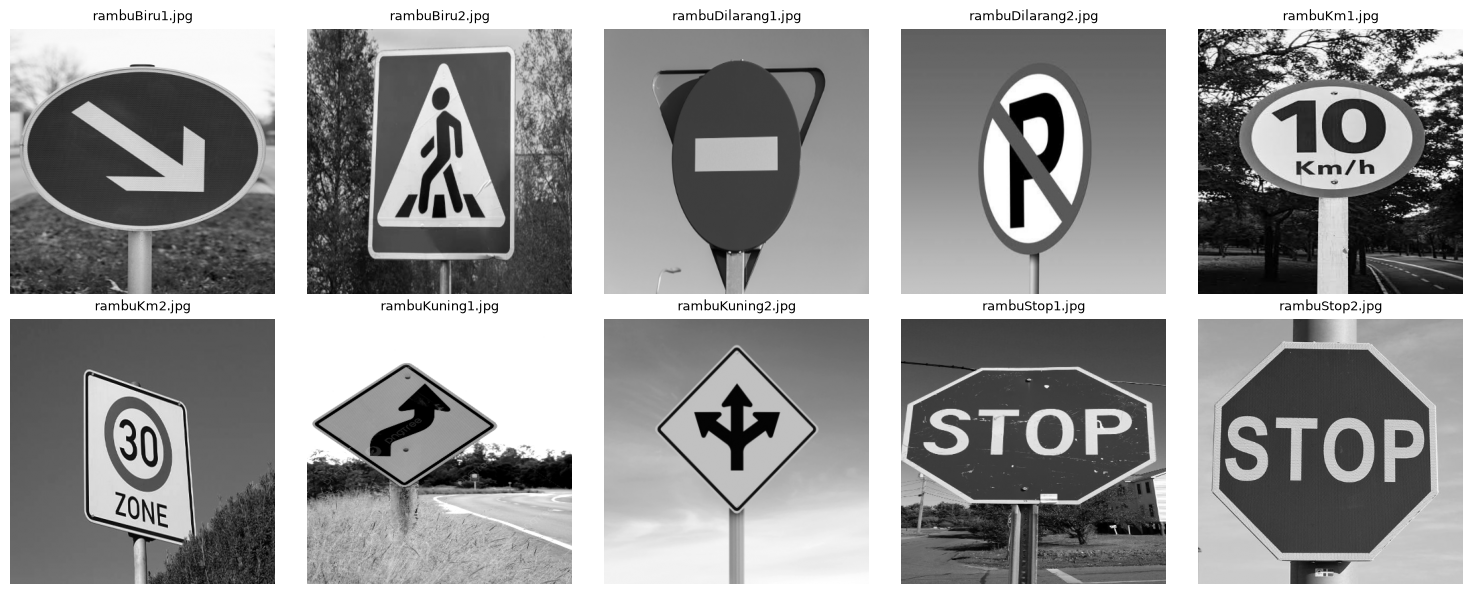

In [3]:
citra_gray_list = [cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in citra_bgr_list]

plt.figure(figsize=(15, 6))
for i, g in enumerate(citra_gray_list):
    plt.subplot(2, 5, i + 1)
    plt.imshow(g, cmap='gray')
    plt.title(nama_list[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

## Tahap 3: Kuantisasi Level Keabuan
Memperkecil dimensi matriks GLCM dari 256 × 256 menjadi 8 × 8 agar performa kode menjadi jauh lebih ringan dan cepat.

Nilai unik hasil kuantisasi (contoh citra pertama): [0 1 2 3 4 5 6 7]


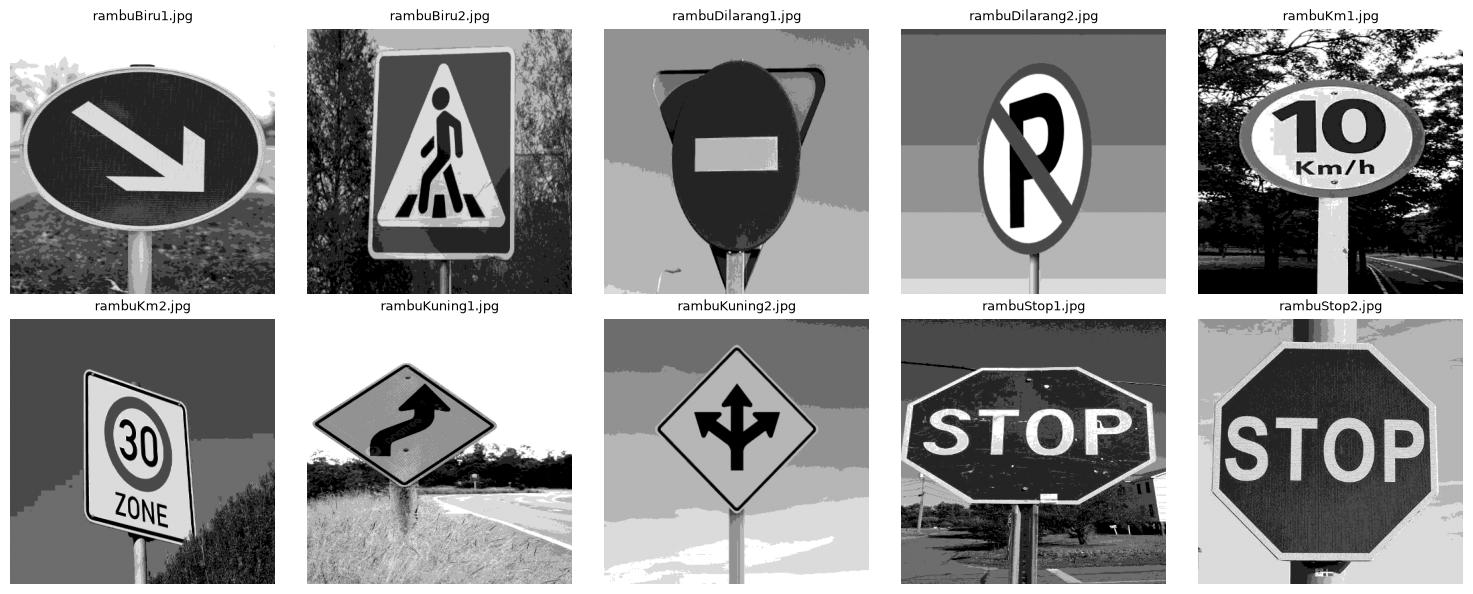

In [4]:
citra_kuantisasi_list = [(g // 32).astype(np.uint8) for g in citra_gray_list]

print("Nilai unik hasil kuantisasi (contoh citra pertama):", np.unique(citra_kuantisasi_list[0]))

plt.figure(figsize=(15, 6))
for i, q in enumerate(citra_kuantisasi_list):
    plt.subplot(2, 5, i + 1)
    plt.imshow(q, cmap='gray', vmin=0, vmax=7)
    plt.title(nama_list[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

## Tahap 4: Ekstraksi Matriks GLCM
Algoritma memetakan hubungan spasial antar piksel tetangga yang posisinya bersebelahan (distances=[1]) ke arah kanan (angles=[0]).

Bentuk matriks GLCM per citra: (8, 8, 1, 1)


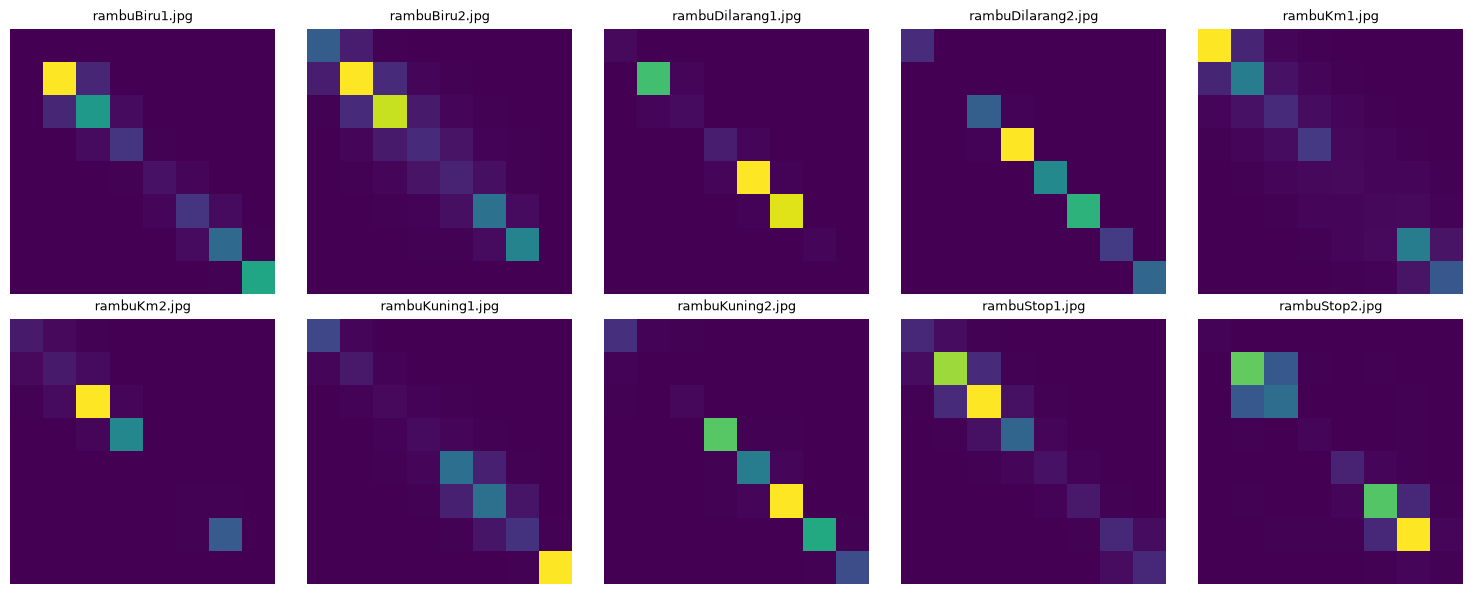

In [5]:
glcm_list = [graycomatrix(q, distances=[1], angles=[0],
                          levels=8, symmetric=True, normed=True)
             for q in citra_kuantisasi_list]

print("Bentuk matriks GLCM per citra:", glcm_list[0].shape)

plt.figure(figsize=(15, 6))
for i, gl in enumerate(glcm_list):
    plt.subplot(2, 5, i + 1)
    plt.imshow(gl[:, :, 0, 0], cmap='viridis')
    plt.title(nama_list[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

## Tahap 5: Mengambil Nilai Fitur Tekstur (Output)
Menghasilkan nilai numerik (vektor fitur) berupa Contrast, Correlation, Energy, dan Homogeneity yang siap dimasukkan ke dalam algoritma klasifikasi Machine Learning.

In [6]:
baris_fitur = []
for nama, kelas, gl in zip(nama_list, kelas_list, glcm_list):
    kontras = graycoprops(gl, 'contrast')[0, 0]
    korelasi = graycoprops(gl, 'correlation')[0, 0]
    energi = graycoprops(gl, 'energy')[0, 0]
    homogenitas = graycoprops(gl, 'homogeneity')[0, 0]
    baris_fitur.append([nama, kelas, kontras, korelasi, energi, homogenitas])

df_fitur = pd.DataFrame(baris_fitur,
                        columns=['Nama_File', 'Kelas', 'Contrast', 'Correlation', 'Energy', 'Homogeneity'])
df_fitur.round(4)

,Nama_File,Kelas,Contrast,Correlation,Energy,Homogeneity
0,rambuBiru1.jpg,Biru,0.1729,0.9850,0.4171,0.9330
1,rambuBiru2.jpg,Biru,0.4134,0.9420,0.3670,0.8763
2,rambuDilarang1.jpg,Dilarang,0.0809,0.9844,0.5327,0.9777
3,rambuDilarang2.jpg,Dilarang,0.1472,0.9741,0.4368,0.9811
4,rambuKm1.jpg,Km,0.7064,0.9488,0.3735,0.8470
5,rambuKm2.jpg,Km,0.4571,0.9098,0.5361,0.9342
6,rambuKuning1.jpg,Kuning,0.3031,0.9686,0.4332,0.9028
7,rambuKuning2.jpg,Kuning,0.1112,0.9783,0.4470,0.9755
8,rambuStop1.jpg,Stop,0.3591,0.9376,0.4273,0.8977
9,rambuStop2.jpg,Stop,0.4230,0.9528,0.4000,0.8739


## Penyimpanan Hasil ke File CSV
Menyimpan fitur hasil ekstraksi ke file CSV menggunakan library bawaan Python `csv`.

In [7]:
nama_file_csv = 'hasil_ekstraksi_fitur.csv'

with open(nama_file_csv, mode='w', newline='') as file_csv:
    writer = csv.writer(file_csv)
    writer.writerow(['Nama_File', 'Kelas', 'Contrast', 'Correlation', 'Energy', 'Homogeneity'])
    writer.writerows(baris_fitur)

print(f"[SUKSES] Data fitur telah disimpan ke dalam file: '{nama_file_csv}'")

[SUKSES] Data fitur telah disimpan ke dalam file: 'hasil_ekstraksi_fitur.csv'


## Visualisasi Perbandingan Fitur Antar Rambu
Grafik berikut membandingkan nilai keempat fitur GLCM pada setiap citra.

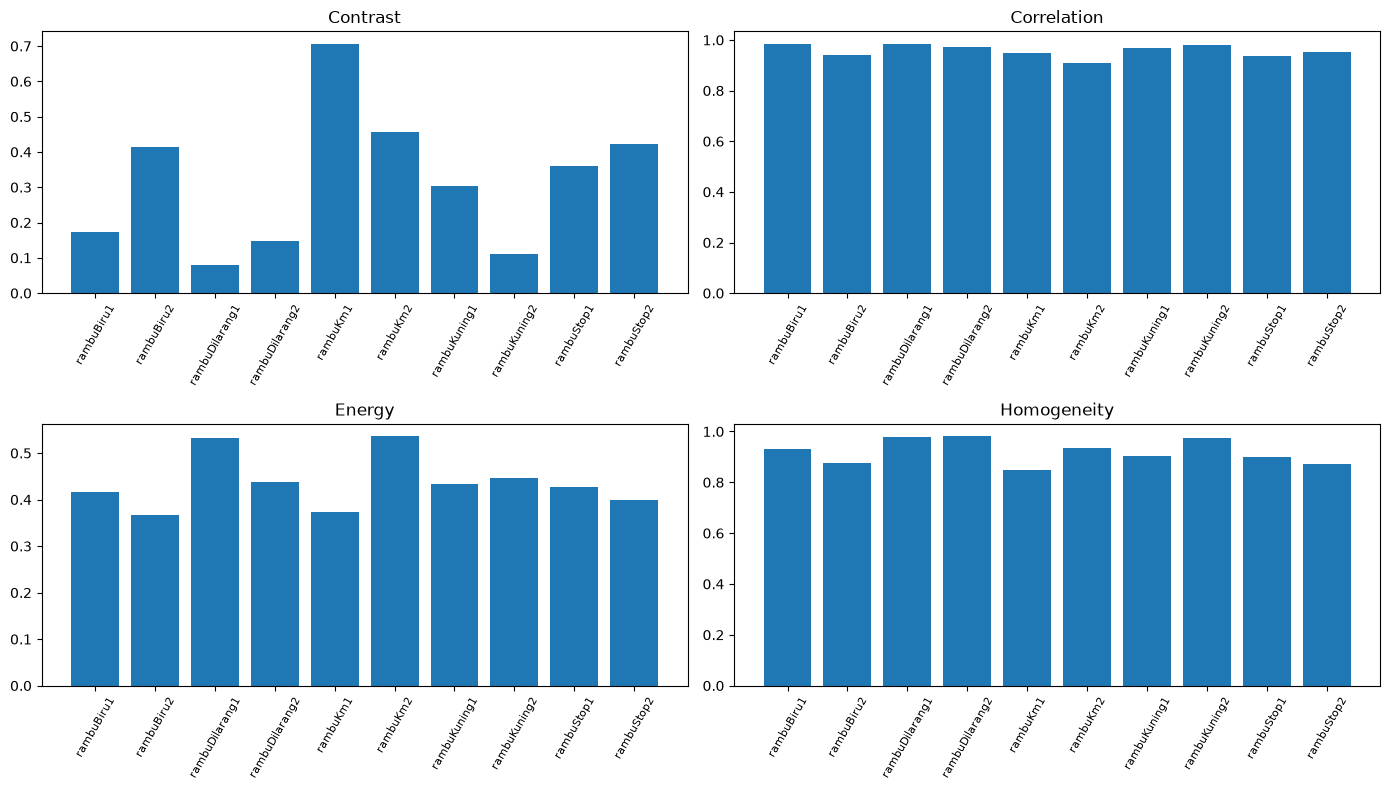

In [8]:
fitur_cols = ['Contrast', 'Correlation', 'Energy', 'Homogeneity']
plt.figure(figsize=(14, 8))
for i, col in enumerate(fitur_cols):
    plt.subplot(2, 2, i + 1)
    plt.bar(df_fitur['Nama_File'].str.replace('.jpg', '', case=False), df_fitur[col])
    plt.title(col)
    plt.xticks(rotation=60, fontsize=8)
plt.tight_layout()
plt.show()

## Interpretasi Hasil Ekstraksi

Ekstraksi GLCM (d=1, θ=0°, 8 level) pada 10 citra rambu (5 jenis × 2 citra) menghasilkan:

- **Contrast** paling bervariasi (≈0,08 pada rambuDilarang1 sampai ≈0,71 pada rambuKm1). Nilai tinggi berarti perbedaan intensitas antar piksel bertetangga besar.
- **Correlation** hampir sama di semua citra (≈0,91–0,99), jadi kurang membedakan antar rambu.
- **Energy** berkisar ≈0,37–0,54 (tertinggi rambuKm2 dan rambuDilarang1), menunjukkan tekstur yang lebih seragam pada citra tersebut.
- **Homogeneity** berkisar ≈0,85–0,98 dan berlawanan dengan Contrast: citra ber-Contrast tinggi (rambuKm1) punya Homogeneity paling rendah.
- Dua citra dari jenis rambu yang sama tidak selalu mirip nilainya (contoh: rambuKm1 dan rambuKm2), karena GLCM dihitung dari seluruh citra termasuk latar dan pencahayaan.

## Tahap 6: Seleksi Fitur (Filter Method: Pearson Correlation)
Menghitung korelasi antar fitur GLCM. Fitur yang berkorelasi sangat tinggi (|r| > 0,9) dianggap redundan, sehingga salah satunya dibuang.

             Contrast  Correlation  Energy  Homogeneity
Contrast        1.000       -0.715  -0.432       -0.875
Correlation    -0.715        1.000  -0.042        0.495
Energy         -0.432       -0.042   1.000        0.680
Homogeneity    -0.875        0.495   0.680        1.000


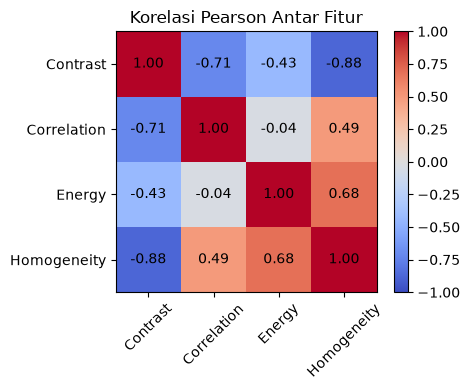

In [9]:
matriks_korelasi = df_fitur[fitur_cols].corr(method='pearson')
print(matriks_korelasi.round(3))

plt.figure(figsize=(5, 4))
plt.imshow(matriks_korelasi, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(4), fitur_cols, rotation=45)
plt.yticks(range(4), fitur_cols)
for i in range(4):
    for j in range(4):
        plt.text(j, i, f"{matriks_korelasi.iloc[i, j]:.2f}", ha='center', va='center')
plt.title("Korelasi Pearson Antar Fitur")
plt.tight_layout()
plt.show()

In [10]:
ambang = 0.9
dibuang = set()
for i in range(len(fitur_cols)):
    for j in range(i + 1, len(fitur_cols)):
        if abs(matriks_korelasi.iloc[i, j]) > ambang:
            dibuang.add(fitur_cols[j])

fitur_terpilih = [f for f in fitur_cols if f not in dibuang]
print("Fitur dibuang  :", list(dibuang) if dibuang else "tidak ada")
print("Fitur terpilih :", fitur_terpilih)

df_terpilih = df_fitur[['Nama_File', 'Kelas'] + fitur_terpilih]
df_terpilih.to_csv('hasil_seleksi_fitur.csv', index=False)
print(f"\n[SUKSES] {len(fitur_terpilih)} fitur terpilih disimpan ke 'hasil_seleksi_fitur.csv'")

Fitur dibuang  : tidak ada
Fitur terpilih : ['Contrast', 'Correlation', 'Energy', 'Homogeneity']

[SUKSES] 4 fitur terpilih disimpan ke 'hasil_seleksi_fitur.csv'


### Hasil Seleksi

Seleksi fitur dengan Filter Method (korelasi Pearson, ambang |r| > 0,9) menunjukkan bahwa **tidak ada pasangan fitur yang redundan**, sehingga keempat fitur dipertahankan: Contrast, Correlation, Energy, dan Homogeneity.

- Korelasi terkuat adalah **Contrast–Homogeneity** (r ≈ −0,88), disusul **Contrast–Correlation** (r ≈ −0,72). Keduanya masih di bawah ambang.
- Pasangan lain memiliki |r| ≤ 0,68 (Energy–Homogeneity 0,68; Correlation–Homogeneity 0,50; Contrast–Energy −0,43; Correlation–Energy −0,04), sehingga relatif independen.

**Kesimpulan:** seluruh fitur (4 dari 4) dipakai sebagai vektor fitur akhir dan disimpan di `hasil_seleksi_fitur.csv`. Karena jumlah sampel hanya 10 citra, metode Wrapper dan Embedded tidak diterapkan karena hasilnya kurang stabil pada data sekecil ini.